# 2색 배색 분석 모델을 코드로 재현하기

영상의 그림 6은 두 색을 세 가지 도형으로 분해해서 본다.

| 도형 | 읽는 값 | HSL 좌표 |
|---|---|---|
| 가운데 원 (색상환) | 두 색의 **각도**, 보색·유사색 관계 | $H$ (hue, 0°~360°) |
| 양옆 삼각형 | 각 색의 **명도·채도** 위치 | $(S, L)$ — hue를 고정한 단면 |
| 바깥 마름모꼴 (bicone) | 두 색의 **3차원 좌표** | $(S\cos H,\ S\sin H,\ L)$ |

즉 **"위치(각도)와 톤(높이·반지름)을 분리해서 본다"**는 말은,
한 색을 $(H, S, L)$ 원기둥 좌표로 쓰고 $H$와 $(S, L)$을 따로 비교한다는 뜻이다.
아래에서는 영상의 16쌍 전체에 이 모델을 적용한다.

In [1]:
import colorsys
import math

import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _show(fig):
    try:
        from IPython import get_ipython
        if get_ipython() is not None:
            fig.show()
    except ImportError:
        pass


# 영상에 나온 16가지 2색 조합 (이름 A, HEX A, 이름 B, HEX B)
PAIRS = [
    ("세이지그린", "#719470", "연분홍", "#E0B3B6"),
    ("아이보리", "#F5ECC2", "연하늘", "#A7D4E4"),
    ("오렌지", "#D96629", "틸블루", "#0093A5"),
    ("로즈핑크", "#DA525D", "민트그린", "#00B49B"),
    ("커피브라운", "#71502F", "올리브그린", "#788860"),
    ("자홍", "#B73F74", "진파랑", "#005B8D"),
    ("라임옐로우", "#C7D14F", "진보라", "#501345"),
    ("연노란", "#FFEFAE", "다크올리브", "#42533E"),
    ("앰버", "#F3A257", "커피브라운", "#71502F"),
    ("살구", "#FDD4BD", "파랑", "#006EB8"),
    ("황토", "#C27544", "라벤더", "#B5B1D8"),
    ("테라코타", "#C55347", "회분홍", "#C0A9B3"),
    ("솔잎", "#437742", "감청", "#064F6E"),
    ("옥색", "#00978D", "라벤더", "#B5B1D8"),
    ("빨강", "#CC1236", "흑녹", "#0F1A14"),
    ("코럴", "#F48067", "미드나잇블루", "#051230"),
]


def hex_to_hsl(hex_str):
    """'#RRGGBB' -> (H[deg], S[0..1], L[0..1]).  colorsys는 (h, l, s) 순서로 돌려준다."""
    r, g, b = (int(hex_str[i:i + 2], 16) / 255 for i in (1, 3, 5))
    h, l, s = colorsys.rgb_to_hls(r, g, b)
    return h * 360, s, l


def hue_gap(h1, h2):
    """색상환 위 두 각도의 최단 차이 (0~180°). 180°에 가까우면 보색."""
    d = abs(h1 - h2) % 360
    return min(d, 360 - d)


print(hex_to_hsl("#C7D14F"))  # 라임옐로우
print(hex_to_hsl("#501345"))  # 진보라

(64.6153846153846, 0.5855855855855855, 0.5647058823529412)
(310.81967213114757, 0.6161616161616161, 0.19411764705882353)


## 1. 16쌍을 HSL로 분해한 표

색상환 관계는 각도 차 $\Delta H$로 읽고, 톤 관계는 채도 $S$·명도 $L$과 그 차이로 읽는다.
영상에서 "보색"이라 부른 쌍은 $\Delta H \approx 180°$, "유사색"은 $\Delta H$가 작다.
"비대칭"이라 부른 쌍(라임옐로우·진보라, 살구·파랑, 빨강·흑녹, 코럴·미드나잇블루)은 $\Delta L$이 크다.

In [2]:
rows = []
for name_a, hex_a, name_b, hex_b in PAIRS:
    ha, sa, la = hex_to_hsl(hex_a)
    hb, sb, lb = hex_to_hsl(hex_b)
    rows.append((name_a, hex_a, ha, sa, la, name_b, hex_b, hb, sb, lb, hue_gap(ha, hb), abs(la - lb)))

hdr = f"{'#':>2} {'색 A':<7}{'H':>5}{'S':>5}{'L':>5}   {'색 B':<8}{'H':>5}{'S':>5}{'L':>5}   {'ΔH':>5} {'ΔL':>5}"
print(hdr)
print("-" * len(hdr))
for i, (na, xa, ha, sa, la, nb, xb, hb, sb, lb, dh, dl) in enumerate(rows, 1):
    print(f"{i:>2} {na:<7}{ha:>5.0f}{sa*100:>4.0f}%{la*100:>4.0f}%   "
          f"{nb:<8}{hb:>5.0f}{sb*100:>4.0f}%{lb*100:>4.0f}%   {dh:>4.0f}° {dl*100:>4.0f}%")

 # 색 A        H    S    L   색 B         H    S    L      ΔH    ΔL
-----------------------------------------------------------------
 1 세이지그린    118  14%  51%   연분홍       356  42%  79%    122°   28%
 2 아이보리      49  72%  86%   연하늘       196  53%  77%    146°    9%
 3 오렌지       21  70%  51%   틸블루       187 100%  32%    166°   18%
 4 로즈핑크     355  65%  59%   민트그린      172 100%  35%    177°   24%
 5 커피브라운     30  41%  31%   올리브그린      84  17%  45%     54°   14%
 6 자홍       334  49%  48%   진파랑       201 100%  28%    132°   21%
 7 라임옐로우     65  59%  56%   진보라       311  62%  19%    114°   37%
 8 연노란       48 100%  84%   다크올리브     109  14%  28%     60°   56%
 9 앰버        29  87%  65%   커피브라운      30  41%  31%      1°   33%
10 살구        22  94%  87%   파랑        204 100%  36%    177°   51%
11 황토        23  51%  51%   라벤더       246  33%  77%    137°   26%
12 테라코타       6  52%  53%   회분홍       334  15%  71%     32°   18%
13 솔잎       119  29%  36%   감청        198  90%  23%     79°   14%
14 옥색     

## 2. 위치와 톤을 분리해서 보기 — 그림 6의 원 + 삼각형

- **왼쪽(극좌표)** = 그림 6의 가운데 원. 각도 $\theta = H$, 반지름 $r = S$.
  선이 원 중심을 가로지르면 보색, 짧으면 유사색.
- **오른쪽(직교좌표)** = 양옆 삼각형을 한 장에 겹친 것. $x = S$, $y = L$.
  선이 세로로 길면 명도 격차(비대칭), 두 점이 같은 높이면 톤 대칭.

두 그래프의 마커 색은 실제 HEX이고, 같은 쌍은 같은 번호로 선으로 이었다.

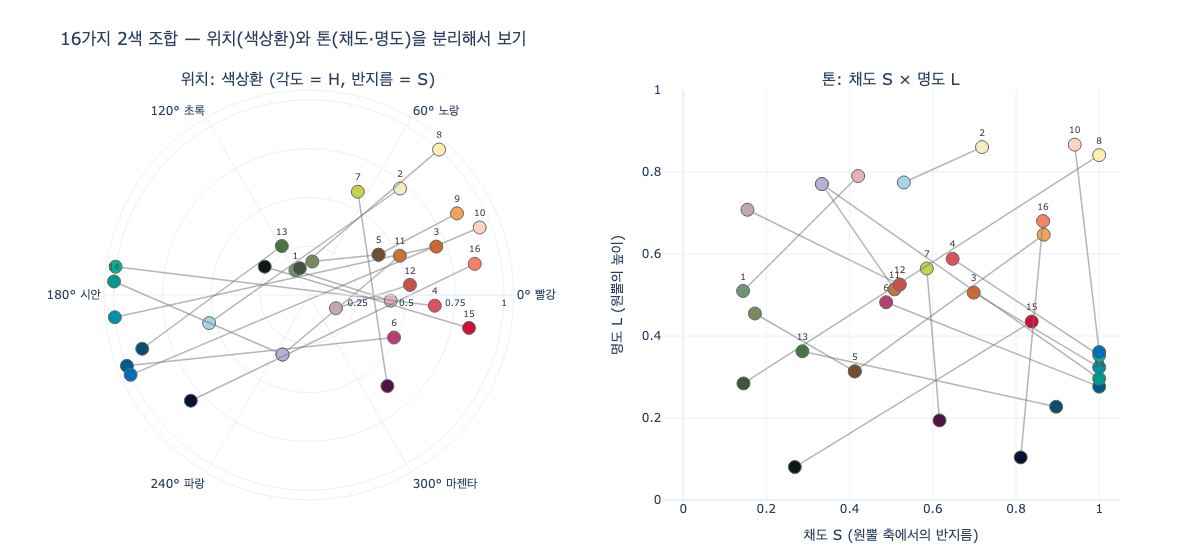

saved expy.png


In [3]:
def build_2panel():
    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{"type": "polar"}, {"type": "xy"}]],
        subplot_titles=("위치: 색상환 (각도 = H, 반지름 = S)", "톤: 채도 S × 명도 L"),
        horizontal_spacing=0.12,
    )
    line_style = dict(color="rgba(120,120,120,0.55)", width=1.5)
    for i, (na, xa, ha, sa, la, nb, xb, hb, sb, lb, dh, dl) in enumerate(rows, 1):
        label = f"{i}. {na} & {nb}"
        # 왼쪽: 색상환
        fig.add_trace(go.Scatterpolar(
            r=[sa, sb], theta=[ha, hb], mode="lines", line=line_style,
            showlegend=False, hoverinfo="skip"), row=1, col=1)
        fig.add_trace(go.Scatterpolar(
            r=[sa, sb], theta=[ha, hb], mode="markers+text",
            text=[str(i), ""], textposition="top center", textfont=dict(size=9, color="#555"),
            marker=dict(size=13, color=[xa, xb], line=dict(color="#666", width=1)),
            name=label, legendgroup=label, showlegend=False,
            hovertext=[f"{na} {xa} H={ha:.0f}° S={sa:.2f} L={la:.2f}",
                       f"{nb} {xb} H={hb:.0f}° S={sb:.2f} L={lb:.2f}"], hoverinfo="text"),
            row=1, col=1)
        # 오른쪽: 톤 평면
        fig.add_trace(go.Scatter(
            x=[sa, sb], y=[la, lb], mode="lines", line=line_style,
            showlegend=False, hoverinfo="skip"), row=1, col=2)
        fig.add_trace(go.Scatter(
            x=[sa, sb], y=[la, lb], mode="markers+text",
            text=[str(i), ""], textposition="top center", textfont=dict(size=9, color="#555"),
            marker=dict(size=13, color=[xa, xb], line=dict(color="#666", width=1)),
            name=label, legendgroup=label, showlegend=False,
            hovertext=[f"{na} {xa}", f"{nb} {xb}"], hoverinfo="text"),
            row=1, col=2)

    fig.update_polars(
        angularaxis=dict(direction="counterclockwise", rotation=0, tickmode="array",
                         tickvals=[0, 60, 120, 180, 240, 300],
                         ticktext=["0° 빨강", "60° 노랑", "120° 초록", "180° 시안", "240° 파랑", "300° 마젠타"]),
        radialaxis=dict(range=[0, 1.05], tickvals=[0.25, 0.5, 0.75, 1.0], tickfont=dict(size=9)),
    )
    fig.update_xaxes(title_text="채도 S (원뿔 축에서의 반지름)", range=[-0.05, 1.05], row=1, col=2)
    fig.update_yaxes(title_text="명도 L (원뿔의 높이)", range=[0, 1], row=1, col=2)
    fig.update_layout(
        title="16가지 2색 조합 — 위치(색상환)와 톤(채도·명도)을 분리해서 보기",
        width=1200, height=560, template="plotly_white", margin=dict(t=90, b=60),
    )
    return fig


fig2d = build_2panel()
fig2d.write_image("expy.png", scale=2)
_show(fig2d)
print("saved expy.png")

## 3. 보너스 — 그림 6의 바깥 마름모꼴: HSL bicone 3D 좌표

HSL 색공간은 두 원뿔을 허리에서 맞댄 **bicone(쌍원뿔)**이다.
위 꼭짓점 $L=1$ 은 흰색, 아래 꼭짓점 $L=0$ 은 검정, 허리 원($L=0.5,\ S=1$)이 순색이다.
원기둥 좌표 $(H, S, L)$을 직교좌표로 바꾸면

$$x = S\cos H,\qquad y = S\sin H,\qquad z = L$$

이다. 그림 6의 마름모꼴은 이 bicone을 옆에서 본 윤곽(위아래 꼭짓점 + 허리 타원)이고,
두 점은 각 색의 $(x, y, z)$ 좌표다. 마름모꼴 옆면(높이 방향 단면)을 잘라내면 삼각형이 되고,
위에서 내려다보면 색상환이 된다 — 세 도형은 같은 물체를 다른 각도에서 본 것이다.

아래 3D 그림은 `_show`로만 표시된다(노트북에서 실행하면 회전해 볼 수 있다).

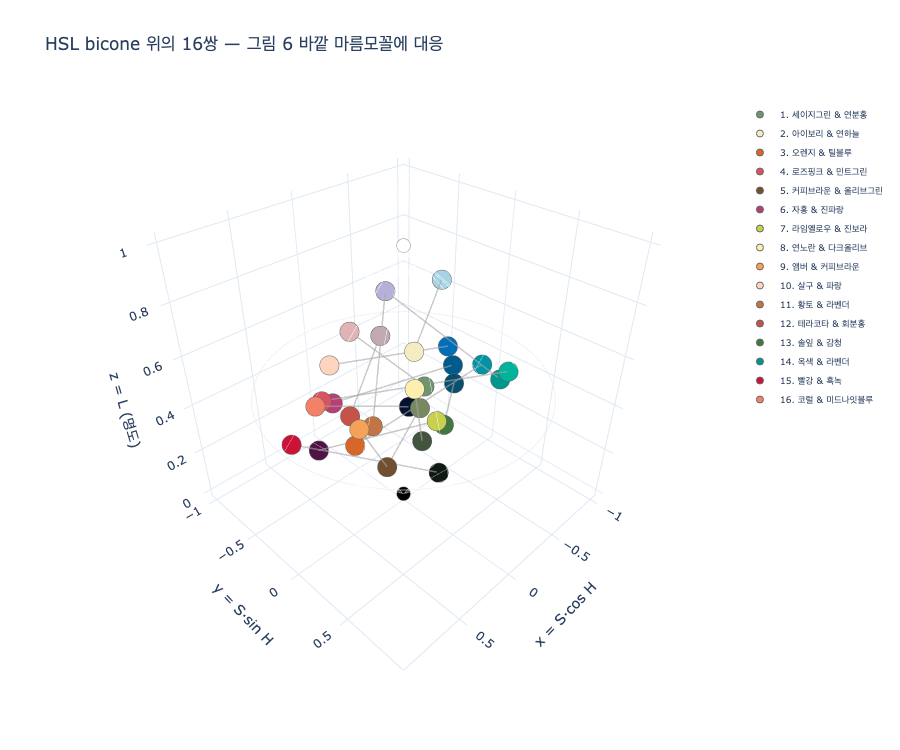

라임옐로우  x=+0.25 y=+0.53 z=0.56
진보라    x=+0.40 y=-0.47 z=0.19


In [4]:
def bicone_wireframe():
    """HSL bicone 윤곽선: 허리 원 + 위/아래 꼭짓점으로 가는 모선 12개."""
    traces = []
    t = [i * 2 * math.pi / 72 for i in range(73)]
    traces.append(go.Scatter3d(
        x=[math.cos(a) for a in t], y=[math.sin(a) for a in t], z=[0.5] * len(t),
        mode="lines", line=dict(color="rgba(140,140,140,0.6)", width=2), showlegend=False, hoverinfo="skip"))
    for k in range(12):
        a = k * 2 * math.pi / 12
        cx, cy = math.cos(a), math.sin(a)
        traces.append(go.Scatter3d(
            x=[0, cx, 0], y=[0, cy, 0], z=[1, 0.5, 0],
            mode="lines", line=dict(color="rgba(140,140,140,0.35)", width=1), showlegend=False, hoverinfo="skip"))
    # 흰색/검정 꼭짓점
    traces.append(go.Scatter3d(x=[0, 0], y=[0, 0], z=[1, 0], mode="markers",
                               marker=dict(size=5, color=["#FFFFFF", "#000000"], line=dict(color="#888", width=1)),
                               showlegend=False, hovertext=["흰색 (L=1)", "검정 (L=0)"], hoverinfo="text"))
    return traces


def build_3d():
    fig = go.Figure(bicone_wireframe())
    for i, (na, xa, ha, sa, la, nb, xb, hb, sb, lb, dh, dl) in enumerate(rows, 1):
        xs = [sa * math.cos(math.radians(ha)), sb * math.cos(math.radians(hb))]
        ys = [sa * math.sin(math.radians(ha)), sb * math.sin(math.radians(hb))]
        zs = [la, lb]
        fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode="lines",
                                   line=dict(color="rgba(100,100,100,0.6)", width=3),
                                   showlegend=False, hoverinfo="skip"))
        fig.add_trace(go.Scatter3d(x=xs, y=ys, z=zs, mode="markers",
                                   marker=dict(size=7, color=[xa, xb], line=dict(color="#666", width=1)),
                                   name=f"{i}. {na} & {nb}",
                                   hovertext=[f"{na} {xa}", f"{nb} {xb}"], hoverinfo="text"))
    fig.update_layout(
        title="HSL bicone 위의 16쌍 — 그림 6 바깥 마름모꼴에 대응",
        width=900, height=750, template="plotly_white",
        scene=dict(xaxis_title="x = S·cos H", yaxis_title="y = S·sin H", zaxis_title="z = L (명도)",
                   aspectmode="cube"),
        legend=dict(font=dict(size=9)),
    )
    return fig


fig3d = build_3d()
_show(fig3d)

# 라임옐로우·진보라의 3D 좌표: 높이(z) 차이가 크고 xy 평면에서는 서로 반대쪽에 있다.
for name, hx in (("라임옐로우", "#C7D14F"), ("진보라", "#501345")):
    h, s, l = hex_to_hsl(hx)
    print(f"{name:<6} x={s*math.cos(math.radians(h)):+.2f} y={s*math.sin(math.radians(h)):+.2f} z={l:.2f}")

## 정리

- **원 (색상환)**: $H$만 본다 → 각도 차 $\Delta H$로 보색/유사색.
- **삼각형**: $H$를 고정하고 $(S, L)$만 본다 → 명도·채도의 위계(대칭/비대칭).
  bicone을 축을 지나는 평면으로 자르면 단면이 삼각형이 되기 때문에 삼각형이다.
- **마름모꼴 (bicone)**: $(H, S, L)$을 한 번에 본다 → 두 점의 높이 차 = 무게 차, 반지름 = 색의 힘(채도).

라임옐로우(z=0.56)와 진보라(z=0.19)는 각도로는 114°로 벌어지면서 높이 차가 0.37이라
"가장 대담하고 위험한" 비대칭 조합으로 분류된다.